Looping through the folders to label parasitized and uninfected images (Label encoding)

In [1]:
import os
import numpy as np
import cv2

data = []
labels = []

img_Size = 128

base_dir = 'cell_images' #we are looping thru the folder
for category in ['Parasitized', 'Uninfected']:
    path = os.path.join(base_dir, category)
    label = 1 if category == 'Parasitized' else 0 #label encoding
    for img in os.listdir(path):
        try:
            img_path = os.path.join(path, img)
            image = cv2.imread(img_path) #reads img as number
            image = cv2.resize(image, (img_Size, img_Size))
            data.append(image) #stores image as numbers
            labels.append(label) #stores parasitized and uninfected
        except:
            pass
#convert pixels to number
data = np.array(data)/255.0
labels = np.array(labels)

data
labels

array([1, 1, 1, ..., 0, 0, 0], shape=(27556,))

Visualize Images

Label value: 1


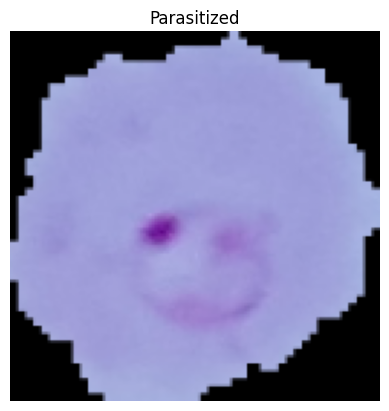

Label value: 1


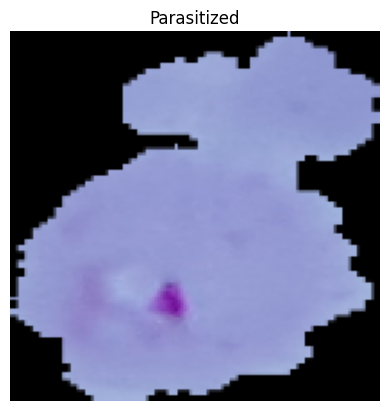

Label value: 1


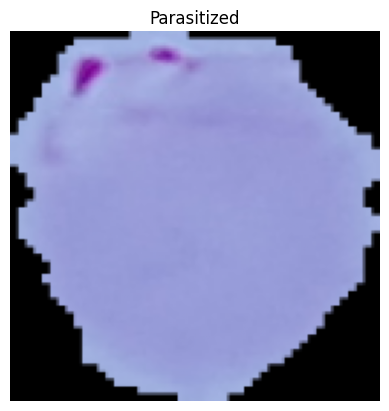

Label value: 1


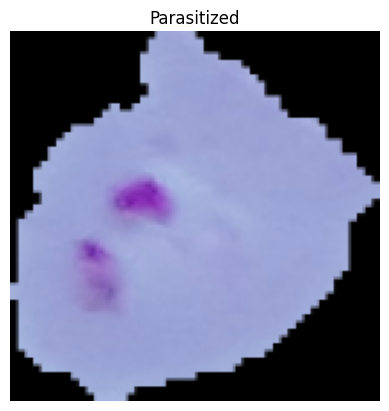

Label value: 1


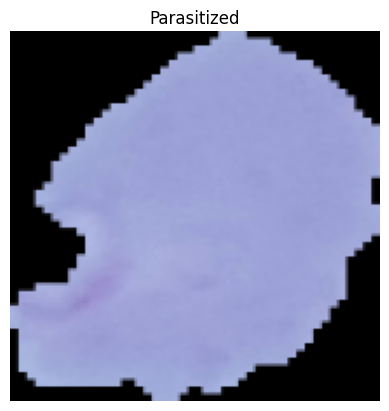

In [2]:
import matplotlib.pyplot as plt

for i in range(5):
    print('Label value:', labels[i])
    plt.imshow(data[i])
    plt.title('Parasitized' if labels[i]==1 else 'Uninfected')
    plt.axis('off')
    plt.show()

Train-Test-Split - 80% for training, 20% for testing

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)
print(X_train.shape)
print(X_test.shape)

(22044, 128, 128, 3)
(5512, 128, 128, 3)


DATA AUGMENTATION

In [4]:
#artificially creates new images from existing ones! Rotating, zoomed, flipped etc

from tensorflow.keras.preprocessing.image import ImageDataGenerator

new_data = ImageDataGenerator(
    rotation_range = 20,
    zoom_range = 0.2,
    horizontal_flip = True
)

In [5]:
print('Training samples:', len(X_train))
print('Testing samples: ', len(X_test))

Training samples: 22044
Testing samples:  5512


Building model now!!

Flow of model:
Take image -> conv -> pool -> conv -> pool -> conv -> pool -> flatten -> Dense -> output

In [7]:
from tensorflow.keras import layers, models, Input
inputs = Input(shape=(128, 128, 3))

#first conv layer - 32 ways of looking at image, 3x3 filter window
x = layers.Conv2D(32, (3, 3), activation='relu')(inputs)
x = layers.MaxPool2D()(x) #make model faster, cutting off unecessary info

x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x) #128 neurons studying the image
x = layers.Dropout(0.5)(x) #half of them turned off to avoid offerfitting

outputs = layers.Dense(1, activation='sigmoid')(x) #sigmoid function maps the pred value between 0 and 1
model = models.Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [8]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Training model

With Data augmentation

In [9]:
train_gen = new_data.flow(X_train, Y_train, batch_size=32) #32 images observed in one go
history = model.fit(
    train_gen,
    epochs=10, #looking at dataset 10 times - improves everytime
    validation_data=(X_test, Y_test) 
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 292s 419ms/step - accuracy: 0.8681 - loss: 0.3251 - val_accuracy: 0.9381 - val_loss: 0.1928
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 290s 420ms/step - accuracy: 0.9394 - loss: 0.1910 - val_accuracy: 0.9528 - val_loss: 0.1581
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 251s 364ms/step - accuracy: 0.9515 - loss: 0.1594 - val_accuracy: 0.9517 - val_loss: 0.1493
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 242s 351ms/step - accuracy: 0.9547 - loss: 0.1496 - val_accuracy: 0.9526 - val_loss: 0.1516
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 309s 448ms/step - accuracy: 0.9549 - loss: 0.1453 - val_accuracy: 0.9550 - val_loss: 0.1350
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 340s 493ms/step - accuracy: 0.9542 - loss: 0.1425 - val_accuracy: 0.9568 - val_loss: 0.1302
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 421s 612ms/step - accuracy: 0.9555 - loss: 0.1408 - val_accuracy: 0.9545 - val_loss: 0.1343
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 341s 464ms/step - accuracy: 0.9566 -

Plot graphs

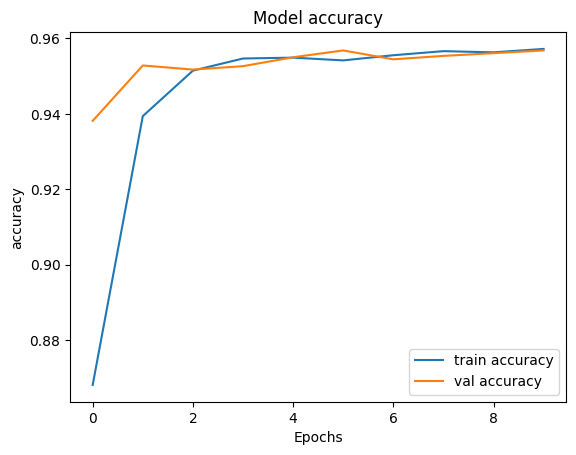

In [10]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Model accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()

Loss

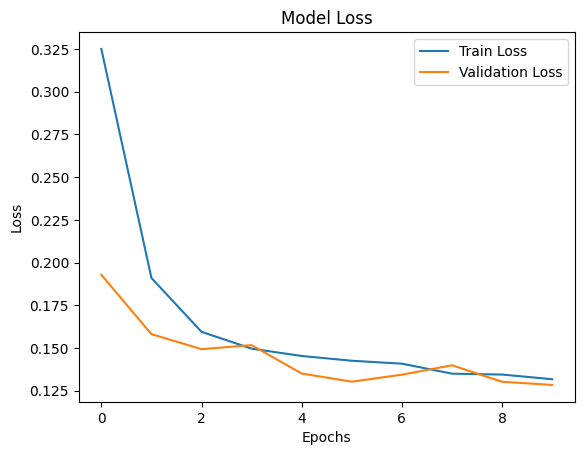

In [11]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Final eval

In [12]:
loss, accuracy = model.evaluate(X_test, Y_test)
print('Test accuracy: ', accuracy)
print('Test loss: ', loss)

173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9568 - loss: 0.1283
Test accuracy:  0.9568215012550354
Test loss:  0.1283344328403473


Predictions and confusion matrix

In [43]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = (model.predict(X_test) > 0.6).astype('int32') #predict and label as 0 or 1 ">0.5" 
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

173/173 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step
[[2642  106]
 [ 133 2631]]
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      2748
           1       0.96      0.95      0.96      2764

    accuracy                           0.96      5512
   macro avg       0.96      0.96      0.96      5512
weighted avg       0.96      0.96      0.96      5512



Hypertuning

In [42]:
from sklearn.metrics import accuracy_score
y_prob = model.predict(X_test)
for threshold in [0.3,0.4, 0.5,0.6,0.7, 0.8]:
    y_pred = (y_prob > threshold).astype("int32")
    acc = accuracy_score(Y_test, y_pred)
    print(f"Threshold: {threshold} and Accuracy: {acc}")

173/173 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step
Threshold: 0.3 and Accuracy: 0.9499274310595065
Threshold: 0.4 and Accuracy: 0.9544629898403484
Threshold: 0.5 and Accuracy: 0.956277213352685
Threshold: 0.6 and Accuracy: 0.9566400580551524
Threshold: 0.7 and Accuracy: 0.956277213352685
Threshold: 0.8 and Accuracy: 0.95355587808418


Testing for one image

In [18]:
import cv2
import numpy as np

image = cv2.imread('C33P1thinF_IMG_20150619_114756a_cell_181.png')
image = cv2.resize(image, (img_Size, img_Size))
image = image/255.0
image = np.reshape(image, (1, 128, 128, 3))
prediction = model.predict(image)
if prediction > 0.5:
    print('Parasitized')
else:
    print('Uninfected')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Parasitized


GRAD-CAM

In [19]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def get_gradcam_heatmap(model, image, layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output] #model looking at last convulation layer because its the most detailed one
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [34]:
def display_gradcam(img, heatmap):
    img = np.array(img)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255*heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    img = np.uint8(img * 255)
    overlay = cv2.addWeighted(img, 0.7, heatmap, 0.3, 0)
    plt.imshow(overlay)
    plt.axis('off')
    plt.show()

Lets check!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
image:  0
Pred score: 4.96469e-06
Final result: Uninfected


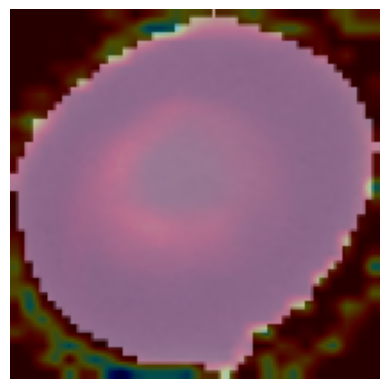

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
image:  1
Pred score: 0.06997697
Final result: Uninfected


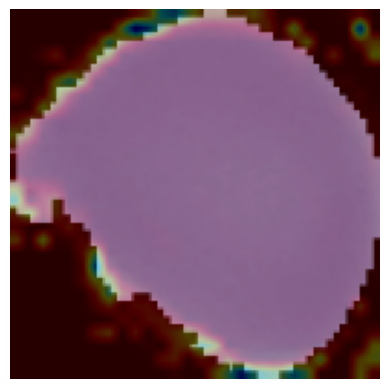

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
image:  2
Pred score: 3.8959126e-07
Final result: Uninfected


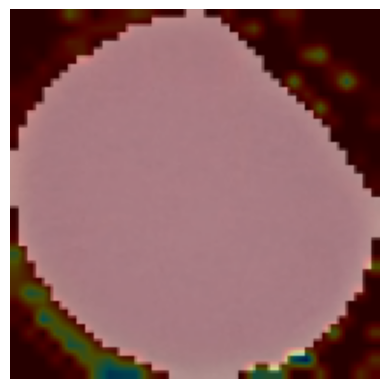

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
image:  3
Pred score: 1.0
Final result: Parasitized


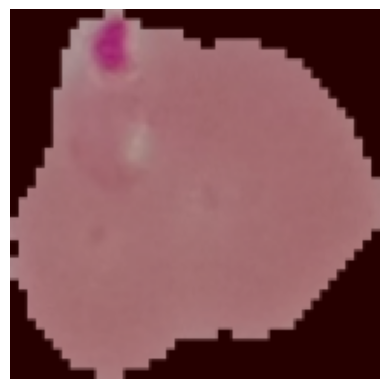

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
image:  4
Pred score: 0.089330725
Final result: Uninfected


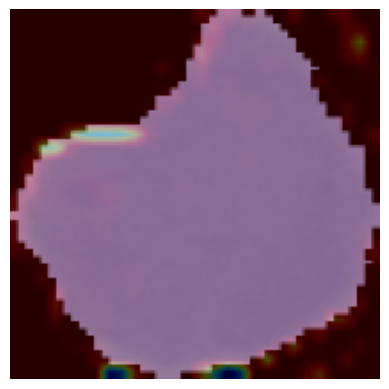

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
image:  5
Pred score: 0.9979039
Final result: Parasitized


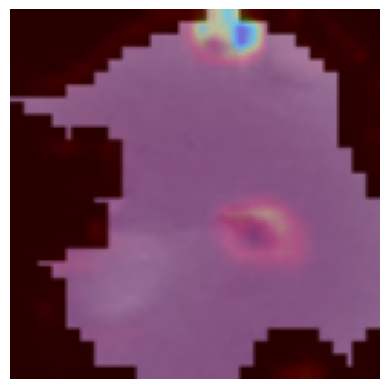

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
image:  6
Pred score: 7.9052974e-05
Final result: Uninfected


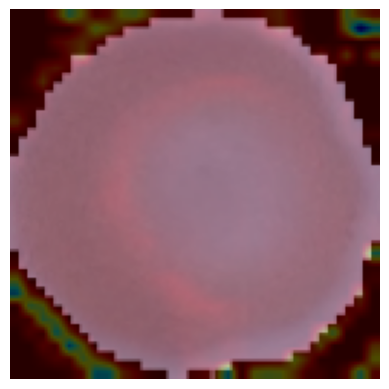

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
image:  7
Pred score: 5.5647473e-05
Final result: Uninfected


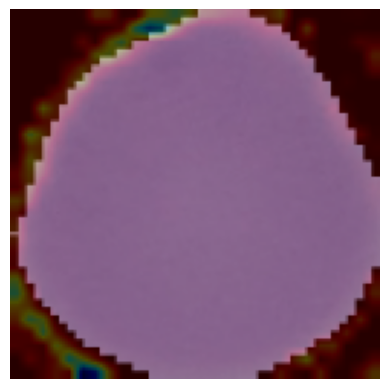

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
image:  8
Pred score: 1.2583822e-05
Final result: Uninfected


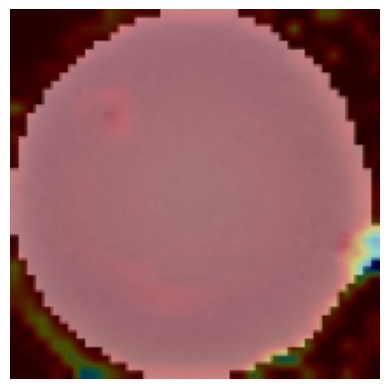

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
image:  9
Pred score: 8.377195e-06
Final result: Uninfected


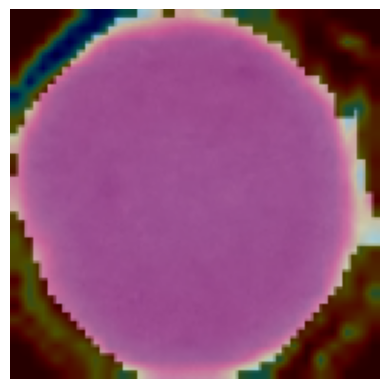

In [38]:
for i in range(10):
    img = X_test[i:i+1]
    pred = model.predict(img)[0][0]
    if pred > 0.5:
        label = 'Parasitized'
    else:
        label = 'Uninfected'
    heatmap = get_gradcam_heatmap(model, img, 'conv2d_5')
    print('image: ', i)
    print('Pred score:', pred)
    print('Final result:', label)

    display_gradcam(X_test[i], heatmap)

Example:
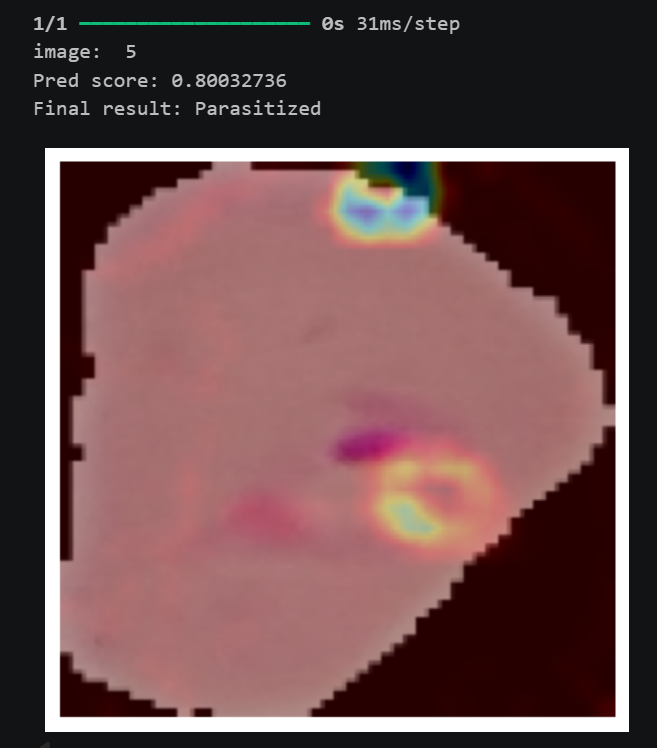